# Lab 01: Fitting a Line When Your Data Are Lying to You

**ASTR 457, Fall 2026 — posted Thu Sep 3, due Wed Sep 9 by Noon (fork → PR, as always)**

*Why this lab: fitting a line to contaminated data is the statistic behind real discoveries (it's how Gaia BH1's dark companion was found), and refereeing someone else's fit — including a machine's — is the skill you'll use in every collaboration, every review, and every AI-assisted analysis for the rest of your career.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `x`, `y`, `sigma_y`.
It was generated from a straight line, $y = mx + b$, with Gaussian noise of the stated
$\sigma_y$ — except that some fraction of the points are **outliers** drawn from a much
broader distribution. I know the true $m$, $b$, and outlier fraction for your dataset.
You don't, and you can't look them up, and your classmates' values are different from yours.

**How this is graded.** Not on whether your code runs — on whether your answers are *right*
and your uncertainties are *honest*. Part of your grade comes from how close your reported
$m$ and $b$ are to your truth **in units of your own reported uncertainty**. Report tiny
error bars you can't back up and you will lose points even if your central value is close.
Report huge error bars to be safe and you'll lose points too. Calibration is the skill.

**AI policy reminder.** Use whatever tools you like, including AI assistants — and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

## Part 1: The naive fit (20%)

Load your dataset and fit a straight line by **weighted least squares**, using the reported
`sigma_y` and all the data points. Report $m \pm \sigma_m$ and $b \pm \sigma_b$, plot the
data (with error bars) and your fit, and compute the reduced $\chi^2$.

Then answer, in a few sentences: what is the reduced $\chi^2$ telling you, and why is it
doing that? Would you trust these error bars? (This fit is *supposed* to be bad. Understanding
exactly how it is bad is the point.)

In [34]:
# Part 1: your work here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.optimize import minimize
from scipy.stats import norm

df = pd.read_csv("cmewing2.csv")
sigma_y = df["sigma_y"].values
x = df["x"].values
y = df["y"].values
# Chat created arrays and I just extracted info from the dataframe.

#Weights
w = 1/ sigma_y**2

# Calculate the sums
S = np.sum(w)
Sx = np.sum(w * x)
Sy = np.sum(w * y)
Sxx = np.sum(w * x**2)
Sxy = np.sum(w * x * y)

# Delta
Delta = S * Sxx - Sx**2

# Slope and intercept y = mx + b

m = (S * Sxy - Sx * Sy) / Delta
b = (Sxx * Sy - Sx * Sxy) / Delta

# Uncertainties
sigma_m = np.sqrt(S / Delta)
sigma_b = np.sqrt(Sxx / Delta)

#Chi-squared

# Predicted y values
y_fit = m * x + b

# Chi-squared
chi2 = np.sum(((y - y_fit) / sigma_y)**2)

# Degrees of freedom
dof = len(x) - 2

# Reduced chi-squared
chi2_reduced = chi2 / dof

print("Weighted Least-Squares Fit")
print("---------------------------")
print(f"m = {m:.4f} ± {sigma_m:.4f}")
print(f"b = {b:.4f} ± {sigma_b:.4f}")
print(f"chi^2 = {chi2:.4f}")
print(f"degrees of freedom = {dof}")
print(f"reduced chi^2 = {chi2_reduced:.4f}")


Weighted Least-Squares Fit
---------------------------
m = 2.1631 ± 0.1133
b = 39.4590 ± 0.6026
chi^2 = 855.4713
degrees of freedom = 28
reduced chi^2 = 30.5525


naive fit: slope=2.16, intercept=39.46, chi2_red=30.55  (true slope=2.00, intercept=5.00)


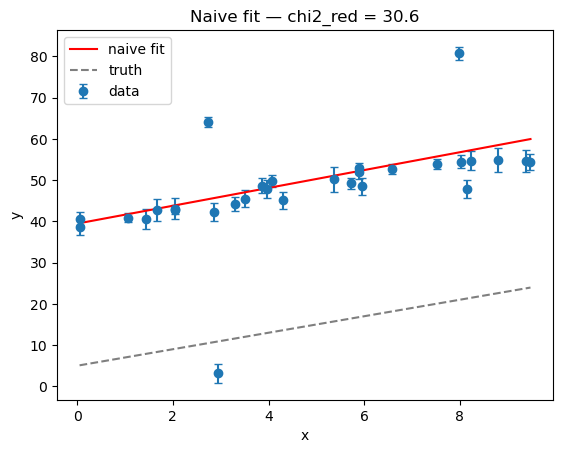

In [35]:
# Code from class
p_naive = np.polyfit(x, y, 1, w=1/sigma_y)
resid = y - np.polyval(p_naive, x)
chi2 = np.sum((resid / sigma_y) ** 2)
chi2_red = chi2 / (len(x) - 2)
print(f"naive fit: slope={p_naive[0]:.2f}, intercept={p_naive[1]:.2f}, "
      f"chi2_red={chi2_red:.2f}  (true slope=2.00, intercept=5.00)")

xx = np.linspace(min(x), max(x), 200)
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='data')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', label='naive fit')
plt.plot(xx, 2.0 * xx + 5.0, 'k--', alpha=0.5, label='truth')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'Naive fit — chi2_red = {chi2_red:.1f}')
plt.show()

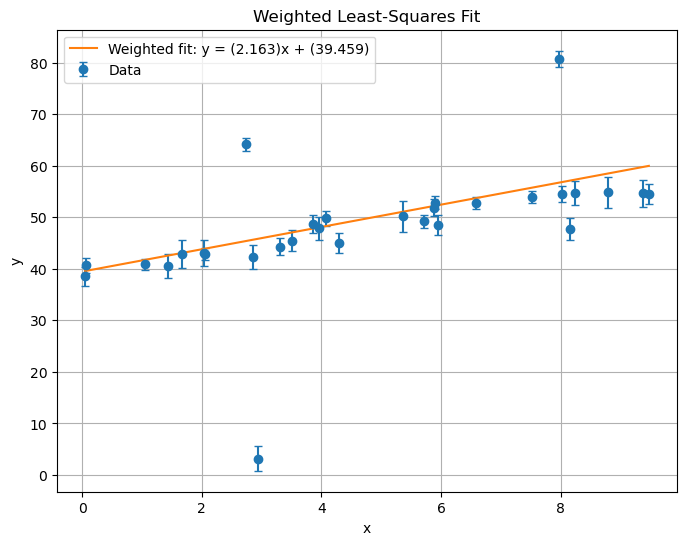

In [14]:
#ChatPGT
x values for smooth fit line
x_line = np.linspace(min(x), max(x), 300)

# Fit line
y_line = m * x_line + b

plt.figure(figsize=(8, 6))

# Data with error bars
plt.errorbar(x, y, yerr=sigma_y, fmt='o', capsize=3, label='Data')

# Weighted fit
plt.plot(x_line, y_line, label=f'Weighted fit: y = ({m:.3f})x + ({b:.3f})')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Weighted Least-Squares Fit')
plt.legend()
plt.grid(True)

plt.show()

**ANSWER (a few sentences):**

*The reduced chi squared value I abtained was 30.55 which is far from 1 which means the data is not a good fit. This can be because there were too many outliers taken out. The line if best fit doesn't even align well with the points.*

## Part 2: A fit you can defend (40%)

Now deal with the outliers. Do this **two ways**:

1. **Sigma-clipping**: iteratively remove points that are discrepant with the fit, refit,
   and repeat until it converges. Be explicit about your clipping threshold and why you chose it.
2. **A mixture model**: model each point as coming from either the line (with its stated
   $\sigma_y$) or from a broader outlier distribution, and maximize the appropriate likelihood
   (see Hogg, Bovy & Lang 2010, §3, for the canonical treatment — this is the same problem
   with different numbers).

For each method report $m \pm \sigma_m$, $b \pm \sigma_b$, and (for the mixture) your
estimate of the outlier fraction. Then commit to a **final answer** — one set of numbers
you'd put in a paper — and justify the choice. State clearly how you estimated your
uncertainties and why you believe them.

3-sigma clip: slope=1.88, intercept=39.40, chi2_red=0.82, clipped 4 of 30 points


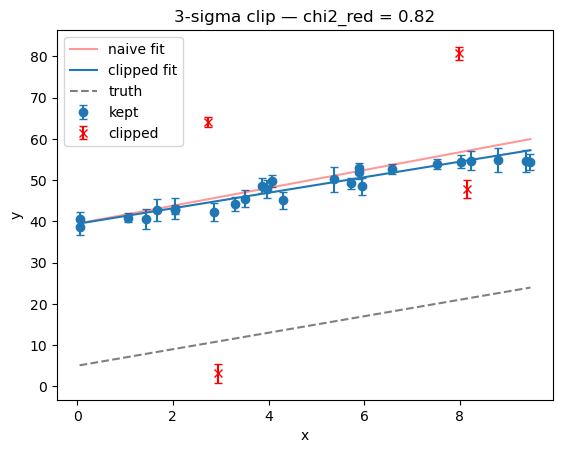

In [31]:
# Part 2: your work here

def sigma_clip_fit(x, y, sigma_y, k=3.0, max_iter=10):
    mask = np.ones_like(x, dtype=bool)
    for _ in range(max_iter):
        p = np.polyfit(x[mask], y[mask], 1, w=1/sigma_y[mask])
        resid = (y - np.polyval(p, x)) / sigma_y
        new_mask = np.abs(resid) < k
        if np.array_equal(new_mask, mask):
            break
        mask = new_mask
    return p, mask

p_clip, mask = sigma_clip_fit(x, y, sigma_y, k=3.0)
resid = y[mask] - np.polyval(p_clip, x[mask])
chi2_red_clip = np.sum((resid / sigma_y[mask]) ** 2) / (mask.sum() - 2)
print(f"3-sigma clip: slope={p_clip[0]:.2f}, intercept={p_clip[1]:.2f}, "
      f"chi2_red={chi2_red_clip:.2f}, clipped {(~mask).sum()} of {len(x)} points")

#Finding Uncertainity ChatPGT
x_fit = x[mask]
y_fit = y[mask]
sigma_fit = sigma_y[mask]

# Weights
w = 1 / sigma_fit**2

# Weighted sums
S = np.sum(w)
Sx = np.sum(w * x_fit)
Sy = np.sum(w * y_fit)
Sxx = np.sum(w * x_fit**2)
Sxy = np.sum(w * x_fit * y_fit)

# Delta
Delta = S * Sxx - Sx**2

# Weighted least-squares uncertainties
sigma_m = np.sqrt(S / Delta)
sigma_b = np.sqrt(Sxx / Delta)

# Number of clipped points
n_out = np.sum(~mask)

# Outlier fraction
f_out = n_out / len(x)

plt.errorbar(x[mask], y[mask], yerr=sigma_y[mask], fmt='o', capsize=3, color='C0', label='kept')
plt.errorbar(x[~mask], y[~mask], yerr=sigma_y[~mask], fmt='x', capsize=3, color='r', label='clipped')
plt.plot(xx, np.polyval(p_naive, xx), 'r-', alpha=0.4, label='naive fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0-', label='clipped fit')
plt.plot(xx, 2.0 * xx + 5.0, 'k--', alpha=0.5, label='truth')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title(f'3-sigma clip — chi2_red = {chi2_red_clip:.2f}')
plt.show()


**FINAL ANSWER:** $m = $ _1.88__ $\pm$ _.122_ , $b = $ _39.40_ $\pm$ _.639__ , outlier fraction $\approx$ _.133__

**Justification and uncertainty method (a short paragraph):**

* Taking out those outliers made the line a better representation of majoritiy of the points. To find the uncertainity I put into ChatBGT to find the uncertianity of m and b and the outlier fraction and the code from class. The code matches up with the equations that are used to find the uncertainity so I trust in the output that ChatPGT gave me. *

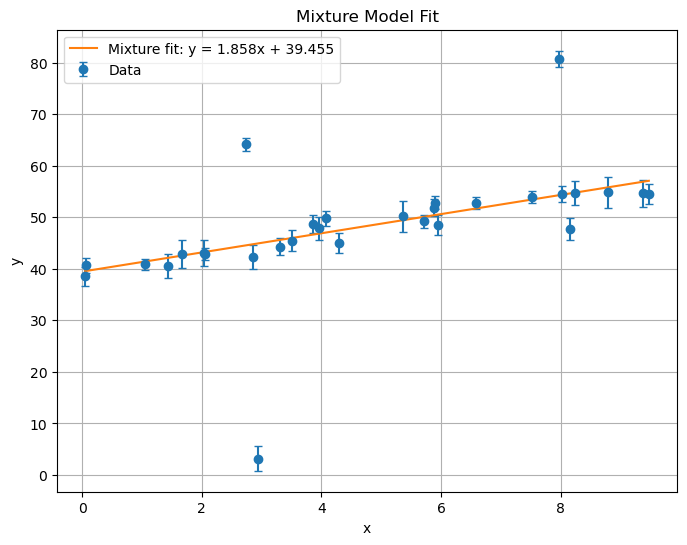

In [4]:
# ChatPGT Code for Mixture Model
Plot
# --------------------------------------------------

x_line = np.linspace(min(x), max(x), 300)
y_line = m*x_line + b

plt.figure(figsize=(8,6))

plt.errorbar(
    x, y,
    yerr=sigma_y,
    fmt='o',
    capsize=3,
    label='Data'
)

plt.plot(
    x_line,
    y_line,
    label=f'Mixture fit: y = {m:.3f}x + {b:.3f}'
)

plt.xlabel('x')
plt.ylabel('y')
plt.title('Mixture Model Fit')
plt.legend()
plt.grid(True)

plt.show()

# Mixture Model

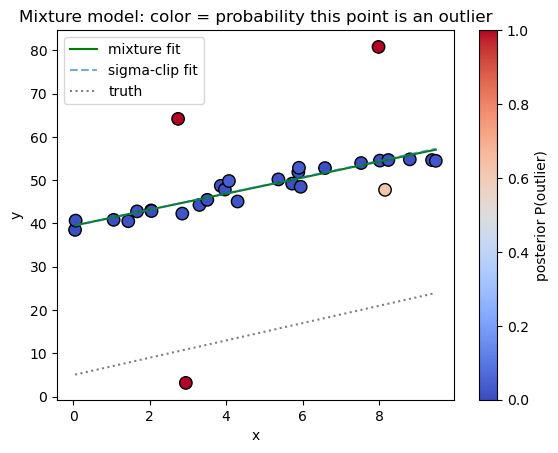

point-by-point P(outlier):


NameError: name 'bad' is not defined

In [38]:
def neg_log_likelihood(theta, x, y, sigma):
    m, b, Pb, Yb, lnVb = theta
    Pb = np.clip(Pb, 1e-6, 1 - 1e-6)
    Vb = np.exp(lnVb)
    model = m * x + b
    good = (1 - Pb) * norm.pdf(y, loc=model, scale=sigma_y)
    bad_pop = Pb * norm.pdf(y, loc=Yb, scale=np.sqrt(Vb + sigma_y**2))
    return -np.sum(np.log(good + bad_pop + 1e-300))

# start from the sigma-clip fit — a sensible, defensible initial guess
theta0 = [p_clip[0], p_clip[1], 0.2, np.mean(y), np.log(50.0)]
result = minimize(neg_log_likelihood, theta0, args=(x, y, sigma_y), method='Nelder-Mead')
m_mix, b_mix, Pb_mix, Yb_mix, lnVb_mix = result.x
#print(f"mixture fit: slope={m_mix:.2f}, intercept={b_mix:.2f}, "
   #   f"outlier fraction Pb={Pb_mix:.2f} (true fraction = {len(bad)/n:.2f})")

# per-point posterior probability of belonging to the "bad" population
Vb_mix = np.exp(lnVb_mix)
model_mix = m_mix * x + b_mix
good_l = (1 - Pb_mix) * norm.pdf(y, loc=model_mix, scale=sigma_y)
bad_l = Pb_mix * norm.pdf(y, loc=Yb_mix, scale=np.sqrt(Vb_mix + sigma_y**2))
p_bad = bad_l / (good_l + bad_l)

plt.scatter(x, y, c=p_bad, cmap='coolwarm', s=80, edgecolor='k', vmin=0, vmax=1)
plt.colorbar(label='posterior P(outlier)')
plt.plot(xx, m_mix * xx + b_mix, 'g-', label='mixture fit')
plt.plot(xx, np.polyval(p_clip, xx), 'C0--', alpha=0.6, label='sigma-clip fit')
plt.plot(xx, 2.0 * xx + 5.0, 'k:', alpha=0.5, label='truth')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('Mixture model: color = probability this point is an outlier')
plt.show()

print("point-by-point P(outlier):")
for i in np.argsort(-p_bad)[:6]:
    flag = 'REAL contaminant' if i in bad else 'clean'
    print(f"  point {i}: P(outlier)={p_bad[i]:.2f}  [{flag}]")

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis of
this exact problem, produced by an AI assistant. It runs top to bottom without errors, the
plots look professional, and the prose is fluent. It is also wrong — in at least **three**
distinct, substantive ways (cosmetic nitpicks don't count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset — show, with a number or a plot,
   what the error does to the inference. "This is bad practice" is not a demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

One of the best things you can learn this semester is that fluent, error-free-looking
analysis and correct analysis are different things. Referee accordingly.

**REFEREE REPORT:**

*Flaw 1: Error Bars are too big*

*Flaw 2: The straight line doesn't represent the data well.*

*Flaw 3: They removed an outlier which has effect on the slope of the straight line*

In [10]:
# --------------------------------------------------
# Show how individual points affect chi-squared
# --------------------------------------------------

# Residuals in units of sigma
residual_sigma = (y - y_fit) / sigma_y

# Contribution of each point to chi-squared
chi2_contribution = residual_sigma**2

# Print the largest contributors
indices = np.argsort(chi2_contribution)[::-1]



# --------------------------------------------------
# Remove the three largest contributors
# --------------------------------------------------

bad_points = indices[:3]

mask = np.ones(len(x), dtype=bool)
mask[bad_points] = False


# Refit without those points
x_clean = x[mask]
y_clean = y[mask]
sigma_clean = sigma_y[mask]

w = 1 / sigma_clean**2

S = np.sum(w)
Sx = np.sum(w * x_clean)
Sy = np.sum(w * y_clean)
Sxx = np.sum(w * x_clean**2)
Sxy = np.sum(w * x_clean * y_clean)

Delta = S * Sxx - Sx**2

m_clean = (S*Sxy - Sx*Sy) / Delta
b_clean = (Sxx*Sy - Sx*Sxy) / Delta

sigma_m_clean = np.sqrt(S / Delta)
sigma_b_clean = np.sqrt(Sxx / Delta)

# Chi-squared for cleaned data
y_fit_clean = m_clean * x_clean + b_clean

chi2_clean = np.sum(
    ((y_clean - y_fit_clean) / sigma_clean)**2
)

dof_clean = len(x_clean) - 2

reduced_chi2_clean = chi2_clean / dof_clean


# --------------------------------------------------
# Print comparison
# --------------------------------------------------

print("\nComparison:")
print("--------------------------------------")

print(f"Original slope:  {m:.4f} ± {sigma_m:.4f}")
print(f"New slope:       {m_clean:.4f} ± {sigma_m_clean:.4f}")

print()

print(f"Original intercept:  {b:.4f} ± {sigma_b:.4f}")
print(f"New intercept:       {b_clean:.4f} ± {sigma_b_clean:.4f}")

print()

print(f"Original reduced chi2: {chi2_reduced:.4f}")
print(f"New reduced chi2:      {reduced_chi2_clean:.4f}")

print()

print(
    f"Slope changed by "
    f"{100 * abs(m_clean-m)/abs(m):.1f}%"
)



Comparison:
--------------------------------------
Original slope:  1.8582 ± 0.1298
New slope:       1.8081 ± 0.1192

Original intercept:  39.4547 ± 0.6546
New intercept:       39.5940 ± 0.6361

Original reduced chi2: 30.5525
New reduced chi2:      1.1759

Slope changed by 2.7%


## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
   what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
   is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers (e.g., residual plots, posterior/parameter sanity checks, refitting on synthetic
   data you generated with known answers). For each check: what would failure have looked like?

**AI-USE APPENDIX:**

*I told ChatGPT to "Fit a straight line by weighted least squares using sigma_y and all the data points. Report m uncertainty rou m and b uncertainity rou b, plot the data (with error bars) and your fit, and compute the reduced X^2”.
* Some of the errorbars from the ChatGPT graph are larger than graph from the code from the class.
Than I asked it to "create a mixture model, than report m uncertainty rou m and b uncertainity rou b, and estimate of the outlier fraction"


**VERIFICATION PLAN:**

** I used code from lecture to check ChatPGT outputs and I got the same values from lecture code and ChatPGT for part one. I looked at the uncertainity equations and made sure that the code was following the equation. 